# Treinando um modelo de Processamento de Linguagem Natural (NLP) utilizando Aprendizagem por Reforço -> Parte 3

Antes de tudo é necessário fazer alguns comentários sobre o repositório que estamos utilizando:

- Este repositório é um fork **modificado** do repositório **nlp_gym** que implementa um ambiente para treinamento de modelos de NLP utilizando Aprendizagem por reforço, através de um ambiente baseado e integrado na biblioteca Gym.

- Para o uso neste projeto algumas partes da estrutura do nlp_gym tiveram que ser modificadas, para resolver problemas de bibliotecas e funções deprecadas, assim como para ficarem compatíveis com os formatos mais recentes do Gym e da biblioteca Stable Baselines.

## NLP utilizando Aprendizagem por Reforço

Agora que compreendemos os fundamentos da Aprendizagem por Reforço e o papel das redes neurais (partes 1 e 2), vamos aplicar esses conceitos especificamente ao **Processamento de Linguagem Natural (NLP)**.

### Por que RL em NLP?

Tradicionalmente, problemas de NLP eram abordados com:

* **Modelos supervisionados**: classificação de texto, análise de sentimento
* **Modelos generativos**: autocompletar, tradução automática

Porém, RL oferece vantagens únicas:

* **Tomada de decisão sequencial**: ideal para tarefas que requerem múltiplas decisões
* **Reward shaping**: permite definir objetivos complexos além da precisão
* **Exploração ativa**: o agente pode aprender estratégias não óbvias
* **Adaptação online**: capacidade de melhorar com feedback contínuo

---

### Por que utilizar embeddings em RL para NLP?

Uma das grandes dificuldades ao aplicar RL diretamente em NLP é que os estados (palavras, sentenças, parágrafos) pertencem a um espaço **altamente dimensional e discreto**. Se tentássemos criar uma Q-table tradicional (tabela explícita com todos os estados e ações), rapidamente seríamos esmagados pela explosão combinatória: há simplesmente **muito mais estados possíveis do que podemos armazenar ou explorar diretamente**.

Por isso, utilizamos **embeddings**, que são representações densas e contínuas (tipicamente vetores de 100 a 1024 dimensões) das palavras, frases ou documentos. Embeddings têm duas funções essenciais:

* **Compactar a informação sem perder semântica** → Palavras ou frases semanticamente semelhantes ficam próximas no espaço vetorial.
* **Reduzir dimensionalidade** → Em vez de trabalhar com milhões de combinações discretas, o agente trabalha em um espaço contínuo, onde redes neurais conseguem generalizar e aprender aproximações.

Isso permite que algoritmos como **Deep Q-Networks (DQN)** ou **policy gradient** usem redes neurais para mapear diretamente desses vetores contínuos para valores Q, probabilidades de ação ou políticas, tornando o aprendizado viável mesmo em ambientes complexos.

---

### Tarefas de NLP como MDPs

O **NLPGym** transforma problemas clássicos de NLP em **Processos de Decisão de Markov (MDPs)**:

| Componente MDP | Aplicação em NLP                                    |
| -------------- | --------------------------------------------------- |
| **Estado**     | Representação atual do texto (embeddings, contexto) |
| **Ação**       | Escolher rótulo, token, continuar lendo, etc.       |
| **Recompensa** | Pontuação baseada em métricas (F1, acurácia, BLEU)  |
| **Transição**  | Como o estado muda após cada ação                   |
| **Política**   | Estratégia para escolher ações dado o estado        |

# NLP Gym

## 1. Introdução
O **NLPGym** transforma problemas de Processamento de Linguagem Natural (NLP) em ambientes de **Reinforcement Learning** seguindo a API do Gym/Gymnasium. Isso permite treinar agentes que **decidem** passo a passo enquanto processam texto.

### Por que importa?
- Permite *reward shaping* e políticas ativas em NLP.
- Facilita benchmarking padronizado de RL em texto.
- Oferece data pools prontos de benchmarks conhecidos.

### Tarefas suportadas
| Tarefa | Descrição |
|---|---|
| **Question Answering (QA)** | Pergunta + contexto + alternativas. O agente decide quando parar de ler opções e qual marcar. Recompensa = 1 se acertar. |
| **Sequence Tagging** | Etiquetagem token‑a‑token (NER, POS). Cada passo rotula um token. Recompensa densa ou F1 final. |
| **Multi‑Label Classification** | Texto pode ter vários rótulos. O agente adiciona rótulos um por vez até terminar. |


Sequence Tagging             |  Question Answering |  Multi-label Classification
:-------------------------:|:-------------------------:|:-------------------------:
<img src="../assets/sequence_tagging.png" width="100%"/> |  <img src="../assets/question_answering.png" width="100%"/> |  <img src="../assets/multilabel.png" width="100%"/> 

## Como Embeddings são Obtidos e Utilizados no NLPGym

## Visão Geral

O NLPGym utiliza **embeddings** como representações vetoriais densas de texto para alimentar os algoritmos de Aprendizagem por Reforço. Os embeddings são essenciais porque convertem texto (dados discretos) em vetores numéricos contínuos que as redes neurais podem processar eficientemente.

## Arquitetura dos Embeddings no Projeto

### 1. **Sistema de Registro de Embeddings**

O projeto utiliza um padrão de registro centralizado para diferentes tipos de embeddings:

```python
# nlp_gym/envs/multi_label/featurizer.py
class EmbeddingRegistry:
    _registry_mapping = {
        "byte_pair": {
            "cls": [BytePairEmbeddings],
            "params": ["en"]
        },
        "fasttext": {
            "cls": [WordEmbeddings],
            "params": ["en-crawl"]
        },
        "stacked": {
            "cls": [WordEmbeddings, BytePairEmbeddings],
            "params": ["en-crawl", "en"]
        }
    }
```

### 2. **Tipos de Embeddings Disponíveis**

#### **a) Word Embeddings (FastText)**
- **Uso**: Representações de palavras pré-treinadas
- **Vantagem**: Captura semântica de palavras individuais
- **Configuração**: `"en-crawl"` para inglês

#### **b) Byte Pair Embeddings (BPE)**
- **Uso**: Subword embeddings para lidar com palavras fora do vocabulário
- **Vantagem**: Melhor generalização para palavras novas
- **Configuração**: `"en"` para inglês

#### **c) Stacked Embeddings**
- **Uso**: Combinação de múltiplos tipos de embeddings
- **Vantagem**: Aproveita benefícios de diferentes representações
- **Implementação**: Concatena Word + BPE embeddings

## Utilização por Tarefa

### 1. **Question Answering**

```python
# nlp_gym/envs/question_answering/featurizer.py
class InformedFeaturizer(ObservationFeaturizer):
    def __init__(self, device: str = "cpu"):
        self.doc_embeddings = DocumentPoolEmbeddings([WordEmbeddings("en")])
    
    def featurize(self, observation: Observation) -> torch.Tensor:
        # Calcula similaridade coseno entre componentes
        sim_scores = [
            self._get_sim(observation.get_question(), observation.get_choice()),
            self._get_sim(".".join(observation.get_facts()), observation.get_choice())
        ]
        return torch.tensor(sim_scores)
```

**Processo:**
1. **Entrada**: Pergunta + Fatos + Opção atual
2. **Embedding**: Cada componente é convertido em vetor denso
3. **Feature**: Calcula similaridade coseno entre pergunta-opção e fatos-opção
4. **Saída**: Vetor de 2 dimensões com scores de similaridade

### 2. **Multi-Label Classification**

```python
# nlp_gym/envs/multi_label/featurizer.py
class DefaultFeaturizerForMultiLabelRank(ObservationFeaturizer):
    def init_on_reset(self, input_text: Union[List[str], str]):
        # Processa o texto de entrada
        text = self.text_pre_processor.process(input_text) if self.pre_process else input_text
        sent = Sentence(text)
        self.doc_embeddings.embed(sent)
        self._current_input_embeddings = torch.tensor(sent.embedding.cpu().detach().numpy())

    def featurize(self, observation: Observation) -> torch.Tensor:
        input_vector = self._current_input_embeddings
        context_vector = self._featurize_context(observation.get_current_action_history())
        concatenated = torch.cat((input_vector, context_vector), dim=0)
        return concatenated
```

**Processo:**
1. **Texto de entrada** → **Document embedding** (representação do documento completo)
2. **Histórico de ações** → **Bag-of-actions vector** (quais rótulos já foram selecionados)
3. **Concatenação**: Input embedding + Context vector
4. **Resultado**: Vetor que representa estado atual + contexto de ações

### 3. **Sequence Tagging**

```python
# nlp_gym/envs/seq_tagging/featurizer.py
class DefaultFeaturizerForSeqTagging(ObservationFeaturizer):
    def init_on_reset(self, input_text: Union[List[str], str]):
        sent = Sentence(input_text)
        self.doc_embeddings.embed(sent)
        # Armazena embedding de cada token separadamente
        self._current_token_embeddings = [token.embedding.cpu().detach() for token in sent]

    def featurize(self, observation: Observation) -> torch.Tensor:
        input_vector = self._featurize_input(observation.get_current_index())
        context_vector = self._featurize_context(observation.get_current_action_history())
        concatenated = torch.cat((input_vector, context_vector), dim=0)
        return concatenated
```

**Processo:**
1. **Tokenização**: Sentença dividida em tokens
2. **Token embedding**: Cada token recebe seu próprio embedding
3. **Contexto**: Representa a última ação tomada
4. **Estado atual**: Token atual + contexto das ações anteriores

## Pipeline de Processamento de Embeddings

### 1. **Inicialização (Reset)**
```python
def init_on_reset(self, input_text):
    # 1. Pré-processamento (opcional)
    text = self.text_pre_processor.process(input_text) if self.pre_process else input_text
    
    # 2. Criação de objeto Sentence (Flair)
    sent = Sentence(text)
    
    # 3. Aplicação dos embeddings
    self.doc_embeddings.embed(sent)
    
    # 4. Extração e armazenamento dos vetores
    self._current_embeddings = [token.embedding.cpu().detach() for token in sent]
```

### 2. **Featurização (Cada Step)**
```python
def featurize(self, observation):
    # 1. Obter embedding da entrada atual
    input_vector = self._get_input_embedding(observation)
    
    # 2. Criar representação do contexto/histórico
    context_vector = self._create_context_vector(observation)
    
    # 3. Combinar informações
    final_vector = torch.cat((input_vector, context_vector), dim=0)
    
    return final_vector
```

## Tratamento de Contexto e Histórico

### **Bag-of-Actions (Multi-Label)**
```python
def _featurize_context(self, context: List[str]) -> torch.Tensor:
    # Cria vetor binário indicando quais ações já foram tomadas
    context_vector = torch.zeros(self.action_space.size())
    action_indices = [self.action_space.action_to_ix(action) for action in context]
    context_vector[action_indices] = 1.0
    return context_vector
```

### **Last-Action (Sequence Tagging)**
```python
def _featurize_context(self, context: List[str]) -> torch.Tensor:
    # Considera apenas a última ação para evitar explosão dimensional
    context_vector = torch.zeros(self.action_space.size())
    context_ = [context[-1]] if len(context) > 0 else []
    action_indices = [self.action_space.action_to_ix(action) for action in context_]
    context_vector[action_indices] = 1.0
    return context_vector
```

## Pré-processamento de Texto

```python
class TextPreProcessor:
    def process(self, text: str) -> str:
        text = text.lower()                    # Minúsculas
        text = self._remove_punctuation(text)  # Remove pontuação
        text = self._remove_digits(text)       # Remove números
        text = self._remove_stop_words(text)   # Remove stop words
        text = self._stem(text)                # Stemming
        return text
```

## Exemplos de uso no NLPGym

## Configuração do Ambiente

Primeiro, vamos configurar o wrapper de compatibilidade entre Gym antigo e Gymnasium moderno:

In [1]:
import gymnasium as gym
from gymnasium import spaces as gs
import gym as ogym
import numpy as np

class CompatEnv(gym.Env):
    """Wrapper que adapta ambientes Gym antigos para Gymnasium."""
    
    def __init__(self, env):
        super().__init__()
        self.env = env
        self.action_space = self._convert(env.action_space)
        self.observation_space = self._convert(env.observation_space)
    
    def _convert(self, space):
        """Converte espaços do Gym antigo para Gymnasium."""
        if isinstance(space, ogym.spaces.Box):
            return gs.Box(low=space.low, high=space.high, dtype=space.dtype)
        if isinstance(space, ogym.spaces.Discrete):
            return gs.Discrete(space.n)
        if isinstance(space, ogym.spaces.Tuple):
            return gs.Tuple(tuple(self._convert(s) for s in space.spaces))
        if isinstance(space, ogym.spaces.Dict):
            return gs.Dict({k: self._convert(v) for k, v in space.spaces.items()})
        return space
    
    def reset(self, *, seed=None, **kw):
        obs = self.env.reset()
        return obs, {}
    
    def step(self, action):
        obs, reward, done, info = self.env.step(action)
        return obs, reward, done, False, info
    
    def render(self, *a, **k):
        return self.env.render(*a, **k)
    
    def close(self):
        self.env.close()

print("Wrapper de compatibilidade configurado")

Wrapper de compatibilidade configurado


## Exemplo Prático: Question Answering com DQN

Vamos implementar um exemplo completo de treinamento para Question Answering usando o dataset QASC:

In [2]:
from nlp_gym.data_pools.custom_question_answering_pools import QASC
from nlp_gym.envs.question_answering.env import QAEnv
from nlp_gym.envs.question_answering.featurizer import InformedFeaturizer
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3 import DQN
import os

# 1. Preparar dados
print("Carregando dataset QASC...")
train_pool = QASC.prepare('train')
val_pool = QASC.prepare('val')
print(f"   Treino: {len(train_pool)} amostras")
print(f"   Validação: {len(val_pool)} amostras")

# 2. Configurar ambiente de treino
print("Configurando ambiente...")
featurizer = InformedFeaturizer()
raw_env = QAEnv(observation_featurizer=featurizer)

# Adicionar amostras ao ambiente
for sample, weight in train_pool:
    raw_env.add_sample(sample, weight)

# Wrapping para compatibilidade
env = DummyVecEnv([lambda: Monitor(CompatEnv(raw_env))])

print("Ambiente configurado")

# 3. Configurar e treinar modelo DQN
print("Configurando modelo DQN...")

model = DQN(
    policy='MlpPolicy',
    env=env,
    learning_rate=1e-4,
    batch_size=32,
    gamma=0.99,
    exploration_fraction=0.1,
    policy_kwargs={"net_arch": [64, 64]},
    verbose=1,
    device='cpu'  # Use 'cuda' se GPU disponível
)

print("Iniciando treinamento...")
model.learn(total_timesteps=20000)

# Salvar modelo
os.makedirs('models', exist_ok=True)
model.save('models/dqn_qa_nlp')
print("Modelo salvo em models/dqn_qa_nlp.zip")

Carregando dataset QASC...
   Treino: 8134 amostras
   Validação: 926 amostras
Configurando ambiente...
Ambiente configurado
Configurando modelo DQN...
Using cpu device
Iniciando treinamento...
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 2.25     |
|    ep_rew_mean      | 0.25     |
|    exploration_rate | 0.996    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 132      |
|    time_elapsed     | 0        |
|    total_timesteps  | 9        |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 1.88     |
|    ep_rew_mean      | 0.125    |
|    exploration_rate | 0.993    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 139      |
|    time_elapsed     | 0        |
|    total_timesteps  | 15       |
----------------------------------
----------------------------------
|

## Avaliação do Modelo

In [3]:
from tqdm import tqdm

def evaluate_qa_model(model, val_pool, num_episodes=100):
    """Avalia o modelo treinado no conjunto de validação."""
    
    # Configurar ambiente de avaliação
    eval_env_raw = QAEnv(observation_featurizer=InformedFeaturizer())
    for sample, weight in val_pool:
        eval_env_raw.add_sample(sample, weight)
    
    eval_env = DummyVecEnv([lambda: Monitor(CompatEnv(eval_env_raw))])
    
    correct_answers = 0
    total_reward = 0
    
    print(f"Avaliando modelo em {num_episodes} episódios...")
    
    for episode in tqdm(range(num_episodes), desc="Avaliação"):
        obs = eval_env.reset()
        done = False
        episode_reward = 0
        
        while not done:
            # Usar política determinística para avaliação
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, info = eval_env.step(action)
            episode_reward += reward[0]  # DummyVecEnv retorna array
        
        total_reward += episode_reward
        if episode_reward > 0:
            correct_answers += 1
    
    accuracy = correct_answers / num_episodes
    avg_reward = total_reward / num_episodes
    
    print(f"   Resultados da avaliação:")
    print(f"   Acurácia: {accuracy:.3f} ({correct_answers}/{num_episodes})")
    print(f"   Recompensa média: {avg_reward:.3f}")
    
    return accuracy, avg_reward

# Avaliar modelo
accuracy, avg_reward = evaluate_qa_model(model, val_pool)


Avaliando modelo em 100 episódios...


Avaliação: 100%|██████████| 100/100 [00:00<00:00, 116.20it/s]

   Resultados da avaliação:
   Acurácia: 0.420 (42/100)
   Recompensa média: 0.420


## Outros Exemplos: Sequence Tagging e Multi-Label

### Sequence Tagging com PPO

PPO é um algorítimo de aprendizagem por reforço mais recente e robusto.

In [4]:
from nlp_gym.data_pools.custom_seq_tagging_pools import UDPosTagggingPool
from nlp_gym.envs.seq_tagging.env import SeqTagEnv
from nlp_gym.envs.seq_tagging.reward import EntityF1Score
from stable_baselines3 import PPO

def train_sequence_tagging_example():
    """Exemplo de treinamento para sequence tagging."""
    
    print("🏷️ Configurando Sequence Tagging...")
    
    # Dados
    train_pool = UDPosTagggingPool.prepare('train')
    labels = train_pool.labels()
    
    # Ambiente
    reward_fn = EntityF1Score(dense=True, average="micro")
    raw_env = SeqTagEnv(
        possible_labels=labels,
        reward_function=reward_fn,
        return_obs_as_vector=True
    )
    
    # Adicionar amostras
    for sample, weight in train_pool:
        raw_env.add_sample(sample, weight)
    
    # Wrapping
    env = DummyVecEnv([lambda: Monitor(CompatEnv(raw_env))])
    
    # Modelo PPO
    model = PPO(
        'MlpPolicy',
        env,
        n_steps=1024,
        batch_size=128,
        verbose=1,
        device='cpu'
    )
    
    print("Treinando PPO para Sequence Tagging...")
    model.learn(total_timesteps=10000)
    
    model.save('models/ppo_seq_tagging')
    print("Modelo sequence tagging salvo")
    
    return model

# Executar exemplo (comentado para não sobrecarregar)
# seq_model = train_sequence_tagging_example()

### Multi-Label Classification com A2C

In [5]:
from nlp_gym.data_pools.custom_multi_label_pools import ReutersDataPool
from nlp_gym.envs.multi_label.env import MultiLabelEnv
from nlp_gym.envs.multi_label.reward import F1RewardFunction
from stable_baselines3 import A2C

def train_multi_label_example():
    """Exemplo de treinamento para multi-label classification."""
    
    print("Configurando Multi-Label Classification...")
    
    # Dados
    train_pool = ReutersDataPool.prepare('train')
    labels = train_pool.labels()
    
    # Ambiente
    reward_fn = F1RewardFunction()
    raw_env = MultiLabelEnv(
        possible_labels=labels,
        max_steps=15,
        reward_function=reward_fn,
        return_obs_as_vector=True
    )
    
    # Adicionar amostras
    for sample, weight in train_pool:
        raw_env.add_sample(sample, weight)
    
    # Wrapping
    env = DummyVecEnv([lambda: Monitor(CompatEnv(raw_env))])
    
    # Modelo A2C
    model = A2C(
        'MlpPolicy',
        env,
        verbose=1,
        device='cpu'
    )
    
    print("Treinando A2C para Multi-Label...")
    model.learn(total_timesteps=15000)
    
    model.save('models/a2c_multi_label')
    print("Modelo multi-label salvo")
    
    return model

# Executar exemplo (comentado para não sobrecarregar)
# ml_model = train_multi_label_example()

## Análise e Visualização dos Resultados

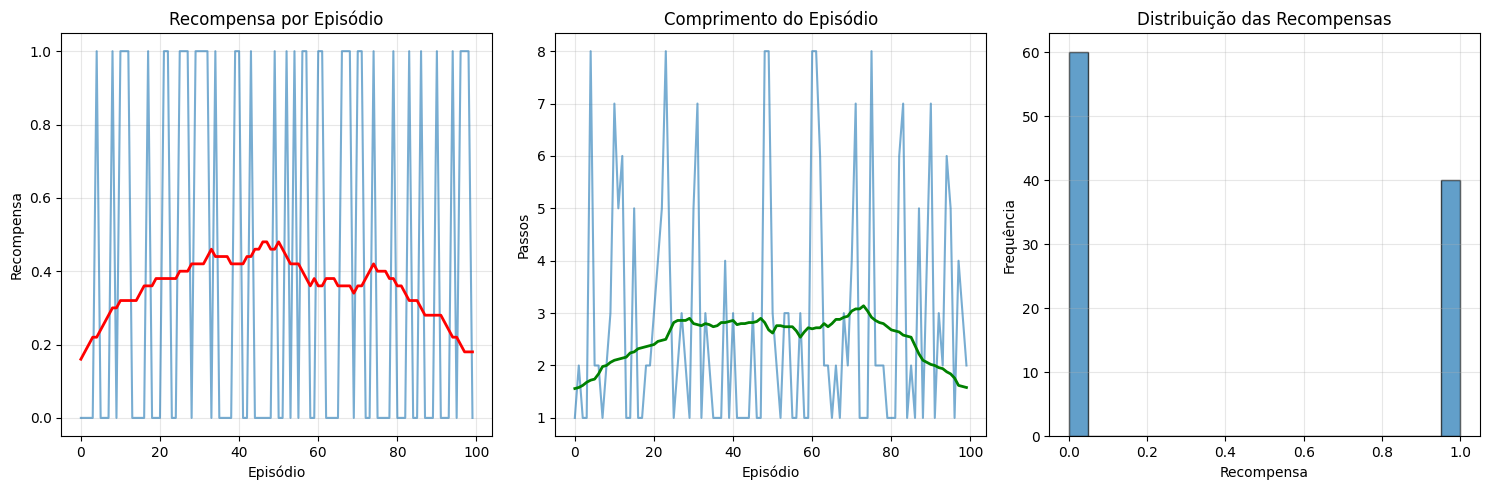

   Estatísticas do treinamento:
   Recompensa média: 0.400 ± 0.490
   Comprimento médio: 2.9 ± 2.2
   Episódios totais: 100


In [6]:
import matplotlib.pyplot as plt
import numpy as np

def plot_learning_progress(model):
    """Plota curvas de aprendizado se dados disponíveis."""
    
    if hasattr(model, 'ep_info_buffer') and len(model.ep_info_buffer) > 0:
        rewards = [ep_info['r'] for ep_info in model.ep_info_buffer]
        episode_lengths = [ep_info['l'] for ep_info in model.ep_info_buffer]
        episodes = range(len(rewards))
        
        plt.figure(figsize=(15, 5))
        
        # Recompensas
        plt.subplot(1, 3, 1)
        plt.plot(episodes, rewards, alpha=0.6)
        plt.plot(episodes, np.convolve(rewards, np.ones(50)/50, mode='same'), 'r-', linewidth=2)
        plt.xlabel('Episódio')
        plt.ylabel('Recompensa')
        plt.title('Recompensa por Episódio')
        plt.grid(True, alpha=0.3)
        
        # Comprimentos de episódio
        plt.subplot(1, 3, 2)
        plt.plot(episodes, episode_lengths, alpha=0.6)
        plt.plot(episodes, np.convolve(episode_lengths, np.ones(50)/50, mode='same'), 'g-', linewidth=2)
        plt.xlabel('Episódio')
        plt.ylabel('Passos')
        plt.title('Comprimento do Episódio')
        plt.grid(True, alpha=0.3)
        
        # Distribuição das recompensas
        plt.subplot(1, 3, 3)
        plt.hist(rewards, bins=20, alpha=0.7, edgecolor='black')
        plt.xlabel('Recompensa')
        plt.ylabel('Frequência')
        plt.title('Distribuição das Recompensas')
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('learning_progress.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"   Estatísticas do treinamento:")
        print(f"   Recompensa média: {np.mean(rewards):.3f} ± {np.std(rewards):.3f}")
        print(f"   Comprimento médio: {np.mean(episode_lengths):.1f} ± {np.std(episode_lengths):.1f}")
        print(f"   Episódios totais: {len(rewards)}")
    else:
        print("Nenhum dado de progresso disponível")

# Plotar progresso do modelo QA
plot_learning_progress(model)

## Exemplo utilizando GPU para o treinamento

In [7]:

import torch, os
device='cuda' if torch.cuda.is_available() else 'cpu'
print('Dispositivo:', device)
if device=='cuda':
    # Reutiliza env QA
    model_gpu = DQN('MlpPolicy', env, learning_rate=1e-4, batch_size=32, device=device, verbose=0)
    model_gpu.learn(total_timesteps=50000)
    model_gpu.save('models/dqn_qa_gpu_demo')
    print('✅ Modelo QA treinado em GPU')
else:
    print('GPU não disponível – pule esta célula')


Dispositivo: cuda
✅ Modelo QA treinado em GPU
